In [1]:
import requests
import json
import matplotlib.pyplot as plt
from collections import defaultdict

In [10]:
def get_data(api_url):
    response = requests.get(api_url)
    if response.status_code == 200:
        return response.json()
    else:
        print(f"Failed to retrieve data. Status code: {response.status_code}")
        return None

def converSoureType(sourceType):
    if (sourceType == 0):
        return "RDMA"
    elif (sourceType == 1):
        return "REDIS"
    elif (sourceType == 2):
        return "HTTP"
    elif (sourceType == 3):
        return "RPC"
    else:
        return "UNKNOWN"

def calculate_average_diff(data):
    averages = defaultdict(lambda: defaultdict(dict))
    source_types = list()
    message_size_kbs = list()

    for message in data:
        source_type = converSoureType(message.get("SourceType"))
        message_size_kb = message.get("MessageSizeInKB")
        if source_type is not None and message_size_kb is not None:
            if source_type not in source_types:
                source_types.append(source_type)
            if message_size_kb not in message_size_kbs:
                message_size_kbs.append(message_size_kb)
    source_types.sort()
    message_size_kbs.sort()
    for message_size_kb in message_size_kbs:
        for source_type in source_types:
            averages[message_size_kb][source_type] = {"sum": 0, "count": 0}
    
    for message in data:
        source_type = converSoureType(message.get("SourceType"))
        message_size_kb = message.get("MessageSizeInKB")
        diff_in_ms = message.get("DiffInMs")

        if source_type is not None and message_size_kb is not None and diff_in_ms is not None:
            averages[message_size_kb][source_type]["sum"] += diff_in_ms
            averages[message_size_kb][source_type]["count"] += 1

    # Calculate averages
    for size, source_types in averages.items():
        for source_type, values in source_types.items():
            values["avg"] = values["sum"] / values["count"]

    return averages

def plot_bar_graph(averages):
    for size, source_types in averages.items():
        source_type_values = list(source_types.keys())
        avg_diff_in_ms = [source_types[source_type]["avg"] for source_type in source_type_values]

        plt.bar(source_type_values, avg_diff_in_ms)
        plt.xlabel('SourceType')
        plt.ylabel(f'Avg DiffInMs for MessageSizeInKB={size} KB')
        plt.title(f'Average DiffInMs for Each SourceType (MessageSizeInKB={size} KB)')
        plt.show()

        # # Set the ticks to be at integers
        # plt.xticks(range(len(source_types)), source_types)

    plt.show()

Average DiffInMs for Each SourceType (per MessageSizeInKB):
{
  "1": {
    "HTTP": {
      "sum": 33,
      "count": 10,
      "avg": 3.3
    },
    "REDIS": {
      "sum": 628,
      "count": 10,
      "avg": 62.8
    },
    "RPC": {
      "sum": 4,
      "count": 10,
      "avg": 0.4
    }
  },
  "10": {
    "HTTP": {
      "sum": 24,
      "count": 10,
      "avg": 2.4
    },
    "REDIS": {
      "sum": 1352,
      "count": 10,
      "avg": 135.2
    },
    "RPC": {
      "sum": 4,
      "count": 10,
      "avg": 0.4
    }
  },
  "50": {
    "HTTP": {
      "sum": 48,
      "count": 10,
      "avg": 4.8
    },
    "REDIS": {
      "sum": 6311,
      "count": 10,
      "avg": 631.1
    },
    "RPC": {
      "sum": 13,
      "count": 10,
      "avg": 1.3
    }
  },
  "100": {
    "HTTP": {
      "sum": 69,
      "count": 10,
      "avg": 6.9
    },
    "REDIS": {
      "sum": 7466,
      "count": 10,
      "avg": 746.6
    },
    "RPC": {
      "sum": 16,
      "count": 10,
      "avg

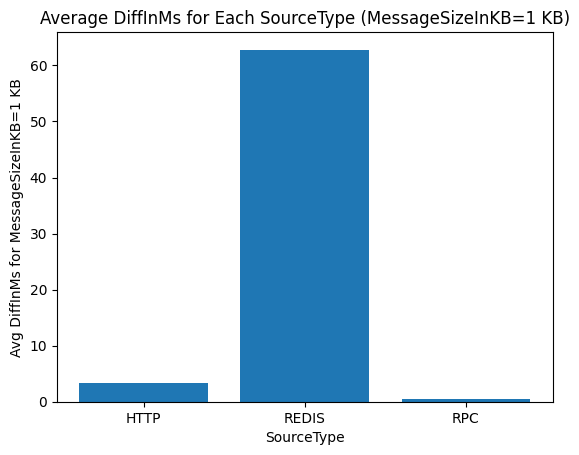

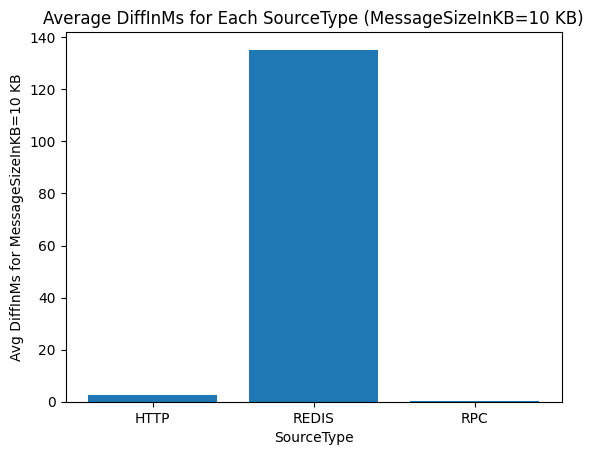

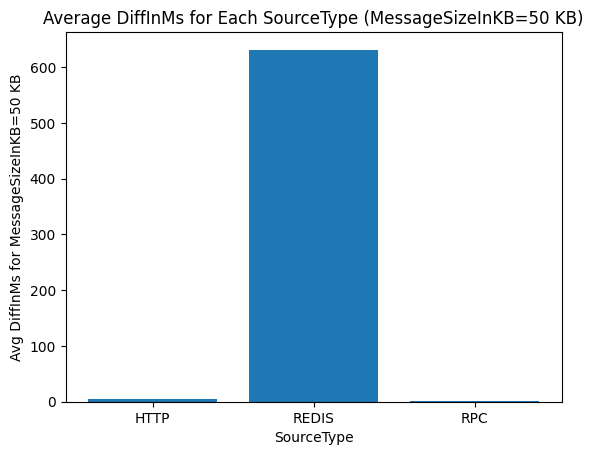

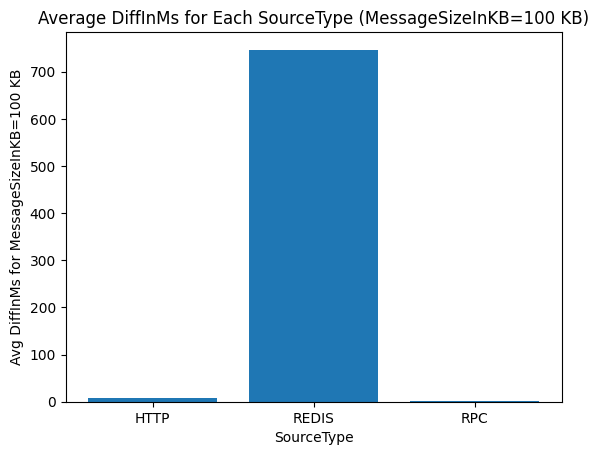

In [11]:
if __name__ == "__main__":
    read_host = "ms1015.utah.cloudlab.us"
    port = "8000"
    api_url = f"http://{read_host}:{port}/getAllData"

    data = get_data(api_url)

    if data:
        averages = calculate_average_diff(data)
        print("Average DiffInMs for Each SourceType (per MessageSizeInKB):")
        print(json.dumps(averages, indent=2))

        plot_bar_graph(averages)